# 13g — Single-Factor Conditional Default under a Climate Factor

This notebook builds the **single-factor Gaussian-copula (Merton/Vasicek) discretization**
of a rating-transition matrix, then conditions it on a systematic ("climate") factor `X`.

The construction, applied to the Kavvathas (2001) 8×8 rounded transition matrix used
throughout this chapter (see the continuity note in `02a_ratings_and_transitions.ipynb`):

1. Convert each row's transition probabilities `p_ij` into cumulative probabilities
   `p_cum = cumsum(p_ij, axis=1)`.
2. Map the cumulative probabilities to standard-normal thresholds via the inverse cdf:
   `z_ij = Φ⁻¹(p_cum)`. The extreme 0%/100% cells give `Φ⁻¹(0) = -∞` / `Φ⁻¹(1) = +∞`
   (and `Φ⁻¹(NaN)` when a row's cumulative sum overshoots 1 by floating-point noise);
   these are capped at `∓Inf_limit` so the thresholds stay finite.
3. Recovering `p_ij` from adjacent thresholds via `Φ(z2) - Φ(z1)` is an exact round-trip
   (this is verified numerically below) — the whole point of the discretization is that
   defining "rating $j$ at $t+1$" as "the systematic+idiosyncratic normal score lands between
   thresholds $z_{i,j-1}$ and $z_{i,j}$" reproduces the unconditional matrix exactly.
4. **Conditioning** on a systematic factor: assume the score is a one-factor Gaussian copula
   `score = √ρ·X + √(1-ρ)·ε`, `ε ~ N(0,1)` idiosyncratic. Conditional on `X`, the transition
   probability becomes `Φ((z2 - √ρ·X)/√(1-ρ)) - Φ((z1 - √ρ·X)/√(1-ρ))`. A positive `X`
   (adverse climate scenario) shifts probability mass toward the lower/default ratings.

Four analyses build on this construction:

- The **full conditional transition matrix** (all origin/destination cells, not just
  default) under one scenario (`X_climate=1`, `ρ=0.20`), `Inf_limit=10`.
- The **default column only**, swept over a 10-point `(X, ρ)` scenario grid, `Inf_limit=7`.
- The same default-column sweep, but first repairing `P` via the
  `logm → estimate_markov_generator → expm` round-trip before re-deriving the
  thresholds — a robustness check that the conditioning still works on the repaired
  generator's implied matrix, which differs slightly from the raw rounded `P`.
- The **minimal single-obligor building block** with no rating matrix at all —
  `p(X) = Φ((Φ⁻¹(PD) - √ρ·X)/√(1-ρ))` for a single `PD=10%` obligor, swept across `X`.

The two default-column-grid analyses share the same computation with only the input `P`
differing, so they are collapsed below into one parametrized helper,
`conditional_default_column_grid(P, Inf_limit)`.


In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import logm, expm
from scipy.stats import norm
from quanttoolbox.sustainable_finance.entropy import estimate_markov_generator

RATINGS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC", "D"]

P_raw = np.array([
    [92.82, 6.50, 0.56, 0.06, 0.06, 0.00, 0.00, 0.00],
    [0.63, 91.87, 6.64, 0.65, 0.06, 0.11, 0.04, 0.00],
    [0.08, 2.26, 91.66, 5.11, 0.61, 0.23, 0.01, 0.04],
    [0.05, 0.27, 5.84, 87.74, 4.74, 0.98, 0.16, 0.22],
    [0.04, 0.11, 0.64, 7.85, 81.14, 8.27, 0.89, 1.06],
    [0.00, 0.11, 0.30, 0.42, 6.75, 83.07, 3.86, 5.49],
    [0.19, 0.00, 0.38, 0.75, 2.44, 12.03, 60.71, 23.50],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 100.00],
])
P_raw = P_raw / P_raw.sum(axis=1, keepdims=True)
K = P_raw.shape[0]
P_raw

array([[9.282e-01, 6.500e-02, 5.600e-03, 6.000e-04, 6.000e-04, 0.000e+00,
        0.000e+00, 0.000e+00],
       [6.300e-03, 9.187e-01, 6.640e-02, 6.500e-03, 6.000e-04, 1.100e-03,
        4.000e-04, 0.000e+00],
       [8.000e-04, 2.260e-02, 9.166e-01, 5.110e-02, 6.100e-03, 2.300e-03,
        1.000e-04, 4.000e-04],
       [5.000e-04, 2.700e-03, 5.840e-02, 8.774e-01, 4.740e-02, 9.800e-03,
        1.600e-03, 2.200e-03],
       [4.000e-04, 1.100e-03, 6.400e-03, 7.850e-02, 8.114e-01, 8.270e-02,
        8.900e-03, 1.060e-02],
       [0.000e+00, 1.100e-03, 3.000e-03, 4.200e-03, 6.750e-02, 8.307e-01,
        3.860e-02, 5.490e-02],
       [1.900e-03, 0.000e+00, 3.800e-03, 7.500e-03, 2.440e-02, 1.203e-01,
        6.071e-01, 2.350e-01],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]])

## Full conditional transition matrix under one climate scenario

Build the thresholds `z_ij` from the raw Kavvathas matrix (`Inf_limit=10`), verify the
round-trip `Φ(z2) - Φ(z1) == p_ij`, then condition the *entire* matrix on
`X_climate=1`, `ρ_climate=0.20`.


In [2]:
def thresholds_from_matrix(P, Inf_limit):
    '''Cumulative-probability thresholds z_ij = Phi^-1(cumsum(p_ij)), with the
    0%/100% (and any floating-point-overshoot NaN) cells capped at +/- Inf_limit.
    Returns z1, z2 (the lower/upper threshold bracketing each destination rating)
    and p_ij (the row-normalized matrix actually used).
    '''
    K = P.shape[0]
    p_ij = P / P.sum(axis=1, keepdims=True)
    p_cum = np.cumsum(p_ij, axis=1)

    with np.errstate(divide="ignore", invalid="ignore"):
        z_ij = norm.ppf(p_cum)
    z_ij = np.where(np.isnan(z_ij), Inf_limit, z_ij)
    z_ij = np.where(z_ij == -np.inf, -Inf_limit, z_ij)
    z_ij = np.where(z_ij == np.inf, Inf_limit, z_ij)

    z1 = np.hstack([-10 * np.ones((K, 1)), z_ij[:, :-1]])
    z2 = np.hstack([z_ij[:, :-1], 10 * np.ones((K, 1))])
    return z1, z2, p_ij


z1_a, z2_a, p_ij_a = thresholds_from_matrix(P_raw, Inf_limit=10)

p_z_ij_a = norm.cdf(z2_a) - norm.cdf(z1_a)
roundtrip_error = np.max(np.abs(p_z_ij_a - p_ij_a))
print(f"Discretization round-trip max |Phi(z2)-Phi(z1) - p_ij| = {roundtrip_error:.2e}")

Discretization round-trip max |Phi(z2)-Phi(z1) - p_ij| = 1.77e-16


In [3]:
X_climate, rho_climate = 1.0, 0.20

epsilon1_a = (z1_a - np.sqrt(rho_climate) * X_climate) / np.sqrt(1 - rho_climate)
epsilon2_a = (z2_a - np.sqrt(rho_climate) * X_climate) / np.sqrt(1 - rho_climate)
p_ij_Z_a = norm.cdf(epsilon2_a) - norm.cdf(epsilon1_a)

df_14a = pd.DataFrame(100 * p_ij_Z_a, index=RATINGS, columns=RATINGS)
df_14a.round(2)

,AAA,AA,A,BBB,BB,B,CCC,D
AAA,87.18,11.62,1.00,0.10,0.09,0.00,0.00,0.00
AA,0.05,86.59,11.84,1.18,0.10,0.18,0.06,0.00
A,0.00,0.32,88.90,9.20,1.11,0.40,0.02,0.06
BBB,0.00,0.02,1.29,87.74,8.51,1.80,0.29,0.36
BB,0.00,0.01,0.06,2.08,79.95,14.38,1.64,1.89
B,0.00,0.00,0.02,0.05,1.70,81.76,6.58,9.89
CCC,0.01,0.00,0.03,0.10,0.50,4.61,56.84,37.91
D,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00


Conditional on the adverse scenario (`X=1`, one standard deviation of systematic risk),
every row's probability mass shifts toward lower ratings/default relative to the unconditional
matrix — e.g. the `D` row is no longer a pure absorbing `100%` since the row is being
re-conditioned on the same factor draw as every other row (the `D`→`D` cell is `Φ(10)-Φ(-∞·adj)`,
still ≈100% since `D` is absorbing regardless of `X`). Row sums must still equal 100%
since conditioning by a single common factor is just a change of the underlying normal's mean,
not of the partition of the real line.

In [4]:
row_sums_a = df_14a.sum(axis=1)
row_sums_a

AAA    100.0
AA     100.0
A      100.0
BBB    100.0
BB     100.0
B      100.0
CCC    100.0
D      100.0
dtype: float64

## Default-column scenario grid, raw vs. repaired `P`

This restricts the thresholds to the **default column only** (`z1`, `z2` sliced to
column `K`, i.e. the boundary between `CCC`→non-default and `CCC`→`D`... more precisely the
column that separates "any rating below D" from "D" for every origin row) and sweeps across
10 `(X_climate, ρ_climate)` combinations, with `Inf_limit=7`. The second pass first repairs
`P` via the generator round-trip (`logm → estimate_markov_generator → expm`, the same repair
used for the climate-stress generator elsewhere in this chapter) before re-deriving the
thresholds — since the repair adjusts `P` slightly to guarantee it is consistent with *some*
valid continuous-time generator, the two resulting grids are expected to differ slightly, not
be duplicates.

Both passes share all their logic except the input `P`, so they are collapsed into one
parametrized helper here.


In [5]:
def conditional_default_column_grid(P, Inf_limit=7):
    '''Default-column-only conditional PD grid across 10 (X_climate, rho_climate)
    scenarios. Returns a DataFrame (rows = origin rating AAA..CCC, columns = scenario
    labels) of conditional P(default | X) in percent.
    '''
    K = P.shape[0]
    z1, z2, _ = thresholds_from_matrix(P, Inf_limit=Inf_limit)
    z1_D = z1[:, K - 1]
    z2_D = z2[:, K - 1]

    X_climate = np.array([10, 1, 1, 1, 2, 2, 2, 3, 3, 3], dtype=float)
    rho_climate = np.array([0.0, 0.20, 0.30, 0.50, 0.20, 0.30, 0.50, 0.20, 0.30, 0.50])

    epsilon1 = (z1_D[:, None] - np.sqrt(rho_climate) * X_climate) / np.sqrt(1 - rho_climate)
    epsilon2 = (z2_D[:, None] - np.sqrt(rho_climate) * X_climate) / np.sqrt(1 - rho_climate)
    p_ij_Z = norm.cdf(epsilon2) - norm.cdf(epsilon1)

    scenario_labels = [f"X={x:g}, rho={r:.2f}" for x, r in zip(X_climate, rho_climate)]
    df = pd.DataFrame(100 * p_ij_Z[: K - 1, :], index=RATINGS[: K - 1], columns=scenario_labels)
    return df


df_14b = conditional_default_column_grid(P_raw, Inf_limit=7)
df_14b.round(2)

,"X=10, rho=0.00","X=1, rho=0.20","X=1, rho=0.30","X=1, rho=0.50","X=2, rho=0.20","X=2, rho=0.30","X=2, rho=0.50","X=3, rho=0.20","X=3, rho=0.30","X=3, rho=0.50"
AAA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
AA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
A,0.04,0.06,0.04,0.01,0.30,0.35,0.31,1.23,2.05,4.08
BBB,0.22,0.36,0.30,0.12,1.45,1.81,2.13,4.61,7.49,15.21
BB,1.06,1.89,1.79,1.19,5.75,7.42,10.40,14.09,21.47,39.78
B,5.49,9.89,10.44,10.36,21.54,27.36,39.69,38.67,52.10,76.99
CCC,23.50,37.91,41.73,49.13,57.62,67.21,83.60,75.56,86.44,97.61


In [6]:
Lambda_raw = logm(P_raw)
Lambda_repaired, _ = estimate_markov_generator(Lambda_raw)
P_repaired = expm(Lambda_repaired).real
P_repaired = P_repaired / P_repaired.sum(axis=1, keepdims=True)

df_14c = conditional_default_column_grid(P_repaired, Inf_limit=7)
df_14c.round(2)

,"X=10, rho=0.00","X=1, rho=0.20","X=1, rho=0.30","X=1, rho=0.50","X=2, rho=0.20","X=2, rho=0.30","X=2, rho=0.50","X=3, rho=0.20","X=3, rho=0.30","X=3, rho=0.50"
AAA,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.05,0.07,0.10
AA,0.01,0.01,0.01,0.00,0.09,0.09,0.06,0.42,0.70,1.29
A,0.04,0.06,0.04,0.01,0.30,0.35,0.31,1.24,2.07,4.11
BBB,0.22,0.36,0.30,0.12,1.45,1.81,2.13,4.61,7.49,15.21
BB,1.06,1.89,1.79,1.19,5.75,7.42,10.40,14.09,21.47,39.78
B,5.49,9.89,10.44,10.36,21.54,27.36,39.69,38.67,52.10,76.99
CCC,23.50,37.91,41.72,49.13,57.62,67.21,83.60,75.56,86.44,97.60


Sanity checks: every cell of both grids lies in `[0, 100]`%; the `X=10, ρ=0` scenario
(the first column) is effectively the *unconditional* default probability restated (an
extreme, near-impossible factor draw combined with zero systematic loading collapses back
to the marginal), and each row's conditional PD rises monotonically as `X` and `ρ` increase
within the swept grid (worse scenario ⇒ higher conditional default probability). The
generator-repair step perturbs `P` only slightly, so the two grids should be close but not
identical.


In [7]:
in_bounds_b = df_14b.to_numpy()
in_bounds_c = df_14c.to_numpy()
print("Raw-P grid within [0,100]%:", bool(np.all((in_bounds_b >= 0) & (in_bounds_b <= 100))))
print("Repaired-P grid within [0,100]%:", bool(np.all((in_bounds_c >= 0) & (in_bounds_c <= 100))))

max_abs_diff = np.max(np.abs(in_bounds_b - in_bounds_c))
mean_abs_diff = np.mean(np.abs(in_bounds_b - in_bounds_c))
print(f"Raw vs. repaired P: max |diff| = {max_abs_diff:.4f} pp, mean |diff| = {mean_abs_diff:.4f} pp")

Raw-P grid within [0,100]%: True
Repaired-P grid within [0,100]%: True
Raw vs. repaired P: max |diff| = 1.2851 pp, mean |diff| = 0.0435 pp


In [8]:
monotone_in_X = np.all(np.diff(in_bounds_b[:, [1, 4, 7]], axis=1) >= -1e-9)
print("Conditional PD non-decreasing as X climate scenario worsens (rho=0.20 column, X=1->2->3):", bool(monotone_in_X))

Conditional PD non-decreasing as X climate scenario worsens (rho=0.20 column, X=1->2->3): True


## Minimal single-obligor conditional PD

The building block that the rating-matrix analyses above generalize: a single obligor with
unconditional `PD=10%` and asset correlation `ρ=0.20`, conditional PD swept across 7
systematic-factor values `X ∈ {-3,...,3}`.


In [9]:
PD, rho = 0.10, 0.20
X_grid = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

B = norm.ppf(PD)
epsilon = (B - np.sqrt(rho) * X_grid) / np.sqrt(1 - rho)
p_conditional = norm.cdf(epsilon)

df_14d = pd.DataFrame({"X": X_grid, "Conditional PD (%)": 100 * p_conditional})
df_14d

,X,Conditional PD (%)
0,-3.0,52.678151
1,-2.0,33.257342
2,-1.0,17.545692
3,0.0,7.595490
4,1.0,2.662930
5,2.0,0.749091
6,3.0,0.167950


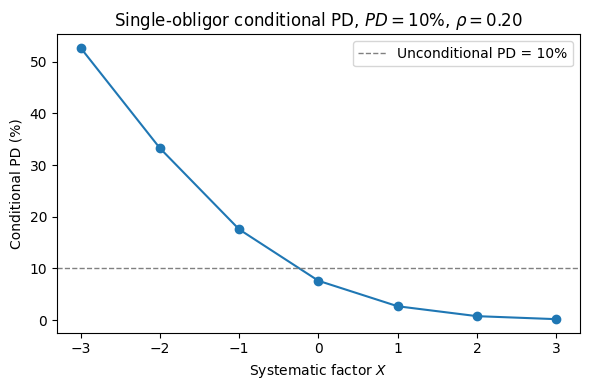

In [10]:
import matplotlib.pyplot as plt

color_blue = "#1f77b4"

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(X_grid, 100 * p_conditional, "o-", color=color_blue, linewidth=1.5)
ax.axhline(100 * PD, linestyle="--", color="gray", linewidth=1, label="Unconditional PD = 10%")
ax.set_xlabel("Systematic factor $X$")
ax.set_ylabel("Conditional PD (%)")
ax.set_title(r"Single-obligor conditional PD, $PD=10\%$, $\rho=0.20$")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
monotone_decreasing = np.all(np.diff(p_conditional) <= 1e-12)
print("Conditional PD strictly decreasing as X rises (favorable systematic factor lowers PD):", bool(monotone_decreasing))
print(f"At X=-3 (adverse): {100*p_conditional[0]:.2f}%   At X=0: {100*p_conditional[3]:.2f}%   At X=+3 (favorable): {100*p_conditional[-1]:.2f}%")

Conditional PD strictly decreasing as X rises (favorable systematic factor lowers PD): True
At X=-3 (adverse): 52.68%   At X=0: 7.60%   At X=+3 (favorable): 0.17%
